# Определения, поля и ограничения данных

Назначение: зафиксировать, что означают поля набора данных и ключевые термины работы
(объект, событие, сессия, терминальное событие, цензура, компонента), чтобы код, ноутбуки и текст диплома
использовали одни и те же понятия. этап 0 плана (п. 1.1).


## 1. Источник данных

- Журнал Windows **System**, собранный скриптом `script.py` с 12 машин.
- Объединённый набор: `data/processed/all_system_logs.csv` (хранится только локально, так как файл большого размера).
- Размер: 372 738 записей, 12 машин (`pc_01` ... `pc_12`).
- Названия машин заменены на анонимные идентификаторы (таблица соответствия хранится только локально).
- Период наблюдения по каждой машине: см. `results/eda/machines_summary.csv`.

## 2. Поля набора данных

| Поле | Тип | Что означает | Откуда |
|---|---|---|---|
| `machine_id` | строка | номер машины (`pc_01` .`pc_12`) | Присвоен при объединении, заменяет `ComputerName` |
| `time` | дата и время | Момент записи события | `TimeGenerated` |
| `event_id` | строка (число) | Номер события внутри источника | `EventID` |
| `source` | строка | Источник (компонент Windows, драйвер или служба), создавший запись | `SourceName` |
| `level` | строка | Уровень (тип) записи | `EventType` |

`event_id` можно рассматривать только вместе с `source`, так как один и тот же номер у разных источников означает разные события. Поэтому событие везде обозначается парой `source:event_id` (в коде это колонка `pair`).

Колонки исходных файлов, которые не вошли в набор: `ComputerName` (персональные данные), `EventCategory`, `EventData`(текст сообщения, который может содержать персональные данные), `Viewer`.

### Значения `level`

| Значение | Смысл |
|---|---|
| `Information` | Информационное сообщение |
| `Warning` | Предупреждение |
| `Error` | Ошибка |
| `0` | уровень критический (`Critical`)записывается как 0, это значение имеют все 219 событий Kernel-Power:41 и 6 записей DriverFrameworks-UserMode. |

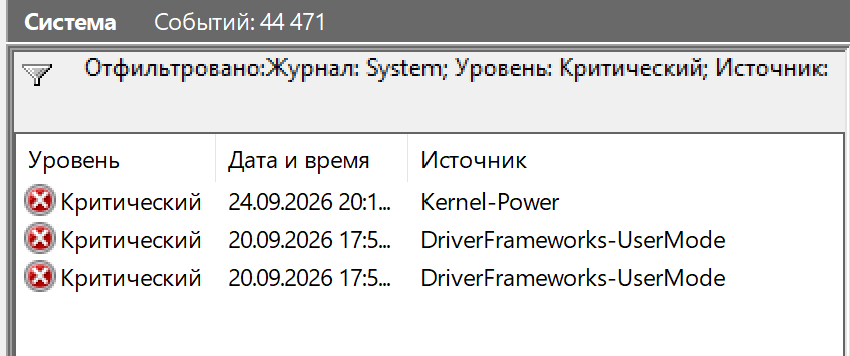

0: типа записи нет в таблице преобразования скрипта сбора script.py (EVENT_TYPE_MAP содержит только Error, Warning, Information, Audit Success, Audit Failure)
Отказ определяется конкретными событиями (`source:event_id`), а не уровнем.

## 3. Возможные события для разметки сессий

| Событие | Смысл | Роль в работе | Кол-во машин на которых встречалось событие |
|---|---|---|---|
| `Microsoft-Windows-Kernel-General:12` |  Системное время запуска операционной системы | Начало сессии | 12 |
| `Microsoft-Windows-Kernel-General:13` |  Системное время завершения работы операционной системы | Конец сессии (штатный) | 10 |
| `EventLog:6005` | Запущена служба журнала событий | Вспомогательная отметка запуска | 12 |
| `EventLog:6006` | Остановка службы журнала событий | Вспомогательная отметка остановки | 10 |
| `User32:1074` | Запрошено выключение или перезагрузка | Признак запланированного завершения | 10 |
| `Microsoft-Windows-Kernel-Power:41` | Система перезагрузилась после некорректного завершения (причины: зависание, критический сбой, потеря питания) | возможное терминальное событие | 9 |
| `EventLog:6008` | 	Предыдущее завершение работы системы было неожиданным | возможное терминальное событие | 9 |
| `disk:154` | сбой операции ввода-вывода из-за ошибки оборудования | может быть связано с деградацией физического оборудования устройства | 2 |
| `Microsoft-Windows-Eventlog:104` |  Файл журнала событий очищен | не событие компонента | 5 |
| `Schannel:36874`, `36888` | Ошибки TLS/SSL-соединений | Шум,не отказ оборудования | 2 |


- Событие `Microsoft-Windows-Kernel-Power:41` записывается в начале новой сессии но относится к предыдущей.

## 4. Определения

### 4.1. Объект

Основной объект анализа это **сессия**: интервал работы машины от **запуска** операционной системы до её **остановки** (штатной/нештатной). 
Машина выступает группирующим признаком.
Идентификатор объекта: `case_id = machine_id + номер сессии`.

### 4.2. Событие

Одна запись журнала System: пара `source:event_id` с меткой времени и уровнем.

### 4.3. Сессия

- Начало: событие `Kernel-General:12` на данной машине.
- Конец: следующее событие запуска на той же машине либо последняя запись журнала.

- `Kernel-Power:41` и `EventLog:6008` формально записываются при старте следующей сессии, но логически завершают предыдущую.

### 4.4. Терминальное событие (отказ)

**Предварительно считаю что это нештатное завершение сессии (`Kernel-Power:41` / `EventLog:6008`).**

так как нештатное завершение не равно отказу компонента. Причиной могут быть отключение питания,
принудительное выключение, зависание или синий экран.

вопрос, что считать отказом

1. любое нештатное завершение считается отказом (проще, это «отказ системы»);
2. отказом компонента считается только нештатное завершение, перед которым были события этой компоненты (например, `disk:154`), остальные считаются цензурой или отдельным исходом (требует больше данных).

### 4.5. Цензура

Сессия считается **цензурированной**, если отказ в ней не наблюдался: время до отказа больше наблюдаемой длительности.
- штатное завершение (`Kernel-General:13`, `User32:1074`); 
- конец журнала при продолжающейся сессии;

Для SA: для каждой сессии записывается пара: **длительность** и **признак события**(1 — отказ, 0 — цензура).

### 4.6. Компонента

**Предварительно считаю что это группа событий журнала System, объединённая по полю `source`**

Для трёх компонент приведены самые частые события журнала System. 
Оперативная память (RAM) в наиболее частых источниках журнала не встретилась.
### disk (хранилище HDD/SSD )

Всего: 13360 записей, 10 машин, 5 EventID.

| EventID | Уровень | Записей | Машин |
|---|---|---|---|
| 154 | Error | 12829 | 2 |
| 51 | Warning | 450 | 5 |
| 11 | Error | 46 | 5 |
| 158 | Warning | 30 | 5 |
| 7 | Error | 5 | 5 |

### Kernel-Power (питание и ядро)

Всего: 5384 записей, 12 машин, 16 EventID.

| EventID | Уровень | Записей | Машин |
|---|---|---|---|
| 172 | Information | 1176 | 9 |
| 566 | Information | 1090 | 2 |
| 109 | Information | 555 | 10 |
| 506 | Information | 450 | 2 |
| 507 | Information | 448 | 2 |
| 42 | Information | 318 | 4 |

### Service Control Manager

Всего: 22745 записей, 12 машин, 15 EventID.

| EventID | Уровень | Записей | Машин |
|---|---|---|---|
| 7040 | Information | 15222 | 12 |
| 7036 | Information | 4694 | 2 |
| 7045 | Information | 758 | 10 |
| 7026 | Error, Information | 754 | 10 |
| 7000 | Error | 633 | 12 |
| 7009 | Error | 461 | 10 |


## 5. Ограничения

1. **Неоднородность.** Шесть машин дают около 87 % записей.
2. **Повторы.** Около 20 % записей (73 954) это полные повторы, серии одинаковых событий (`Schannel`, `disk:154`, `googledrivefs`...)
3. **Мало отказов.** Нештатных завершений 219, из них 199 (91 %) на двух машинах (`pc_01`, `pc_08`);
   на `pc_04`, `pc_05`, `pc_12` их нет.
4. **Машины почти без сессий.** `pc_10` и `pc_11`: 5 и 1 запуск, а событий более 70 тысяч (в основном `Schannel`).
5. **Схожесть поведения.** `pc_02`-`pc_06`, вероятно не независимы.
6. **Уровень `0`** (см. раздел 2). что с ним делать 
7. **Исключённые файлы.** `events_*.csv` не включены.

## 6. Вопросы

1. Что считать отказом: любое нештатное завершение или только связанное с событиями компоненты?
2. Что считать компонентой: один источник или группу источников? 
3. Как обрабатывать повторы: схлопывать подряд идущие или оставить как есть?
4. Что делать с сессиями без начала в журнале?
5. Как добавлять данные и хватит ли этих.
6. Нужны ли файлы `events_*.csv` и что содержит колонка `Viewer`, нужна ли она?
7. Некоторые события имеют несколько различных типов запросов из идентификатора события (как это учитывать?)